In [1]:
import os
import sys

PROJECT_ROOT = os.path.abspath("..")

if PROJECT_ROOT not in sys.path:
    sys.path.append(PROJECT_ROOT)


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [2]:
from src.data.fetchers.market_data import (
    fetch_price_data
)

from src.data.calibration.volatility import (

    compute_log_returns,

    realized_volatility,

    annualized_volatility,
)

In [3]:
btc = fetch_price_data(

    ticker="BTC-USD",

    start="2022-01-01",

    end="2025-01-01"
)

btc_returns = compute_log_returns(
    btc["Close"]
)

daily_vol = realized_volatility(
    btc_returns
)

annual_vol = annualized_volatility(
    btc_returns
)

print("Daily Volatility:", daily_vol)

print("Annualized Volatility:", annual_vol)

[*********************100%***********************]  1 of 1 completed

Daily Volatility: Ticker
BTC-USD    0.028448
dtype: float64
Annualized Volatility: Ticker
BTC-USD    0.451592
dtype: float64



c:\Users\ce81g\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\numpy\_core\fromnumeric.py:4062: FutureWarning: The behavior of DataFrame.std with axis=None is deprecated, in a future version this will reduce over both axes and return a scalar. To retain the old behavior, pass axis=0 (or do not pass axis)
  return std(axis=axis, dtype=dtype, out=out, ddof=ddof, **kwargs)


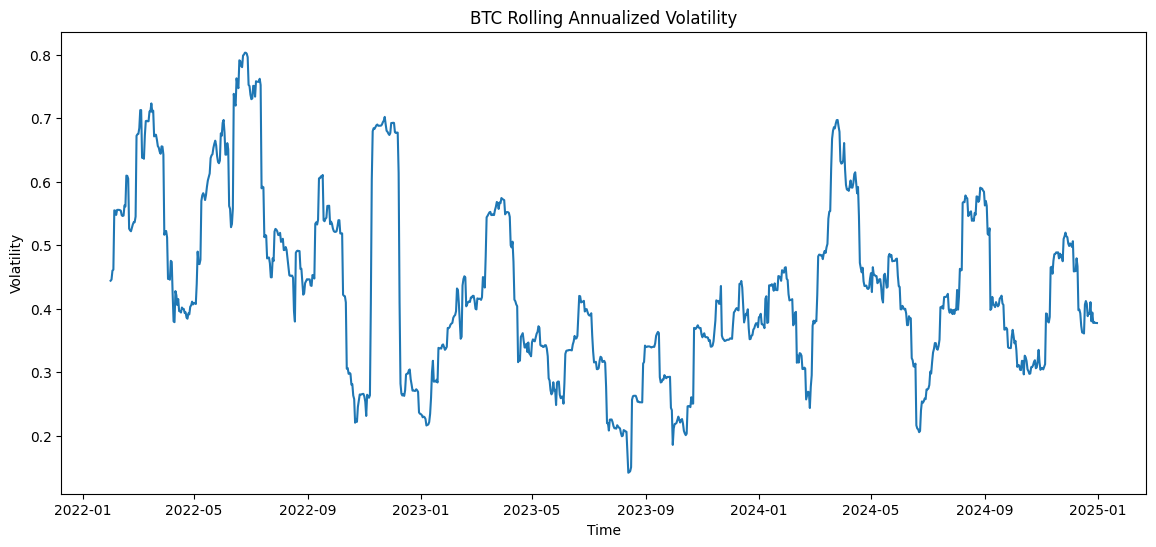

In [4]:
rolling_vol = (

    btc_returns
    .rolling(30)
    .std()
    * np.sqrt(252)
)

plt.figure(figsize=(14, 6))

plt.plot(rolling_vol)

plt.title("BTC Rolling Annualized Volatility")

plt.xlabel("Time")

plt.ylabel("Volatility")

plt.show()

In [5]:
rolling_vol.describe()


Ticker,BTC-USD
count,1066.000000
mean,0.430893
std,0.137846
min,0.141688
25%,0.335211
50%,0.408005
75%,0.521997
max,0.803194


In [6]:
def classify_vol_regime(vol, carry_threshold=0.35, stable_threshold=0.55, stress_threshold=0.75):

    if pd.isna(vol):
        return np.nan

    if vol < carry_threshold:
        return "carry"
    elif vol < stable_threshold:
        return "stable_range"
    elif vol < stress_threshold:
        return "stress"
    else:
        return "panic"

In [7]:
rolling_vol_series = rolling_vol.squeeze()
if isinstance(rolling_vol_series, pd.DataFrame):
    rolling_vol_series = rolling_vol_series.iloc[:, 0]

carry_threshold = 0.35
stable_threshold = 0.55
stress_threshold = 0.75

regimes = rolling_vol_series.apply(
    lambda x: classify_vol_regime(
        x,
        carry_threshold=carry_threshold,
        stable_threshold=stable_threshold,
        stress_threshold=stress_threshold,
    )
)

In [8]:
regimes.head()

Date
2022-01-02    NaN
2022-01-03    NaN
2022-01-04    NaN
2022-01-05    NaN
2022-01-06    NaN
Name: BTC-USD, dtype: object

In [9]:
from collections import Counter
regime_counts = Counter(regimes.dropna())
print("Regime Counts:", regime_counts)
regime_list = regimes.dropna().tolist()
for i in range(len(regime_list) - 1):

    current_regime = regime_list[i]

    next_regime = regime_list[i + 1]

    regime_counts = Counter(regimes.dropna())

    regime_list = regimes.dropna().tolist()


    transition_counts = Counter()

    for i in range(len(regime_list) - 1):
        current_regime = regime_list[i]
        next_regime = regime_list[i + 1]
        transition_counts[(current_regime, next_regime)] += 1

print("Transition Counts:", transition_counts)


Regime Counts: Counter({'stable_range': 524, 'carry': 326, 'stress': 194, 'panic': 22})
Transition Counts: Counter({('stable_range', 'stable_range'): 491, ('carry', 'carry'): 311, ('stress', 'stress'): 173, ('panic', 'panic'): 18, ('stable_range', 'stress'): 17, ('stress', 'stable_range'): 17, ('stable_range', 'carry'): 15, ('carry', 'stable_range'): 15, ('stress', 'panic'): 4, ('panic', 'stress'): 4})


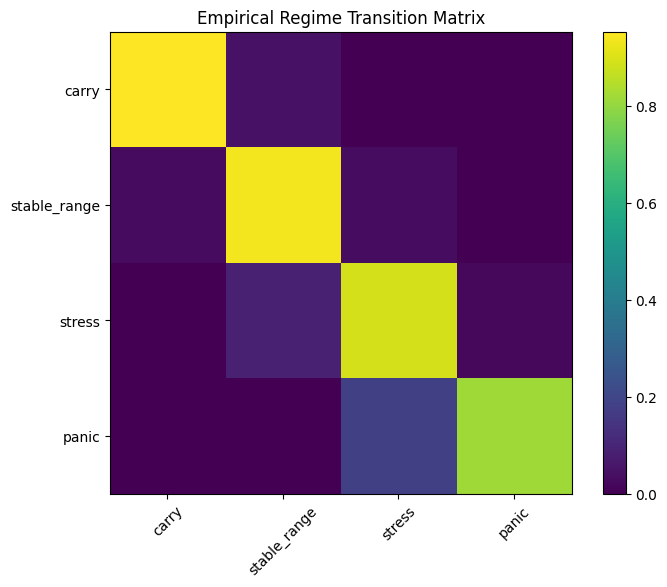

In [10]:
regime_names = [

    "carry",

    "stable_range",

    "stress",

    "panic"
]
transition_matrix = pd.DataFrame(

    0.0,

    index=regime_names,

    columns=regime_names
)

for (current_regime, next_regime), count in transition_counts.items():

    transition_matrix.loc[
        current_regime,
        next_regime
    ] = count


transition_matrix = transition_matrix.div(

    transition_matrix.sum(axis=1),

    axis=0
)

import matplotlib.pyplot as plt
plt.figure(figsize=(8, 6))

plt.imshow(

    transition_matrix,

    interpolation="nearest"
)

plt.xticks(

    range(len(regime_names)),

    regime_names,

    rotation=45
)

plt.yticks(

    range(len(regime_names)),

    regime_names
)

plt.colorbar()

plt.title("Empirical Regime Transition Matrix")

plt.show()

In [ ]:
regimes_clean = regimes.dropna()
panic_mask = regimes_clean == "panic"

panic_days = panic_mask.sum()
total_days = len(regimes_clean)
panic_rarity = panic_days / total_days

runs = (panic_mask != panic_mask.shift()).cumsum()
panic_run_lengths = panic_mask.groupby(runs.values).sum()
panic_run_lengths = panic_run_lengths[panic_run_lengths > 0]

panic_episode_count = len(panic_run_lengths)
average_panic_duration = panic_run_lengths.mean()
median_panic_duration = panic_run_lengths.median()
max_panic_duration = panic_run_lengths.max()

panic_start_dates = regimes_clean.index[panic_mask & ~panic_mask.shift(fill_value=False)]
inter_panic_gaps = panic_start_dates.to_series().diff().dt.days.dropna()

print(f"Panic rarity: {panic_rarity:.3%} ({panic_days}/{total_days} days)")
print(f"Panic episode count: {panic_episode_count}")
print(f"Average panic duration: {average_panic_duration:.2f} days")
print(f"Median panic duration: {median_panic_duration:.2f} days")
print(f"Max panic duration: {max_panic_duration} days")
print(f"Mean gap between panic episode starts: {inter_panic_gaps.mean():.1f} days")

if not inter_panic_gaps.empty:
    print(f"Median gap between panic starts: {inter_panic_gaps.median():.1f} days")

if "panic" in transition_matrix.index and "panic" in transition_matrix.columns:
    print(f"Panic persistence (P(panic->panic)): {transition_matrix.loc['panic','panic']:.3f}")

print("\nPanic run length distribution:")
print(panic_run_lengths.value_counts().sort_index())

Panic rarity: 2.064% (22/1066 days)
Panic episode count: 4
Average panic duration: 5.50 days
Median panic duration: 4.00 days
Max panic duration: 12 days
Mean gap between panic episode starts: 7.0 days
Median gap between panic starts: 3.0 days
Panic persistence (P(panic->panic)): 0.818

Panic run length distribution:
BTC-USD
2     2
6     1
12    1
Name: count, dtype: int64


In [13]:
import os

output_dir = os.path.join(PROJECT_ROOT, "data", "empirical_regimes")
os.makedirs(output_dir, exist_ok=True)

rolling_vol_series.to_frame(name="volatility").to_csv(
    os.path.join(output_dir, "rolling_vol.csv"),
    index=True,
)

regimes.to_frame(name="regime").to_csv(
    os.path.join(output_dir, "regimes.csv"),
    index=True,
)

transition_matrix.to_csv(
    os.path.join(output_dir, "transition_matrix.csv"),
    index=True,
)

print(f"Saved rolling volatility, regimes, and transition matrix to {output_dir}")

Saved rolling volatility, regimes, and transition matrix to c:\Users\ce81g\strategy_allocation\data\empirical_regimes


In [15]:
# Prepare returns series and compute stats conditioned on regime
returns_series = btc_returns.squeeze()
if isinstance(returns_series, pd.DataFrame):
    returns_series = returns_series.iloc[:, 0]

aligned = pd.concat([returns_series.rename("returns"), regimes.rename("regime")], axis=1)
aligned = aligned.dropna(subset=["regime"])  # only days with an assigned regime

grouped = aligned.groupby("regime")["returns"].agg(["count", "mean", "std"]).rename(columns={"std": "daily_std"})
grouped["annualized_mean"] = grouped["mean"] * 252
grouped["annualized_vol"] = grouped["daily_std"] * (252 ** 0.5)

print("Returns conditioned on regime:")
print(grouped)

# Save results
grouped.to_csv(os.path.join(output_dir, "returns_by_regime.csv"))
aligned.to_csv(os.path.join(output_dir, "returns_with_regime.csv"))

print(f"Saved returns_by_regime.csv and returns_with_regime.csv to {output_dir}")

Returns conditioned on regime:
              count      mean  daily_std  annualized_mean  annualized_vol
regime                                                                   
carry           326  0.001573   0.018908         0.396456        0.300159
panic            22 -0.003380   0.038579        -0.851807        0.612421
stable_range    524  0.001005   0.027844         0.253332        0.442007
stress          194 -0.000327   0.039950        -0.082477        0.634179
Saved returns_by_regime.csv and returns_with_regime.csv to c:\Users\ce81g\strategy_allocation\data\empirical_regimes
